## Potential problems in linear regression
##### This document explores common problems that may arise when fitting a linear regression model with examples using synthetic data.

### Issue 1: Non-linearity of the response-predictor relationships

A linear regression model assumes that there is a linear relationship between the predictors and the response, but if the true relationship is not linear then the conclusions we draw about the data from the fit might not be correct. We can detect non-linearity in our data by using residual plots, which plot the residuals against the predictor or in the case of multiple regression the predicted values of y<sub>i</sub>. If the plot shows a pattern such as a U-shape, it indicates non-linearity in the data. To address this, we can take the approach of selecting non-linear transformations to apply to the predictors (like our polynomial example) in the regression model.

A question that came up was what aspects of the linear model might be causing a pattern in the residual plot. The most common diagnoses of residual plots showing patterns were that the model needs a non-linear transformation, the model was lacking a variable, or there were influential outliers.

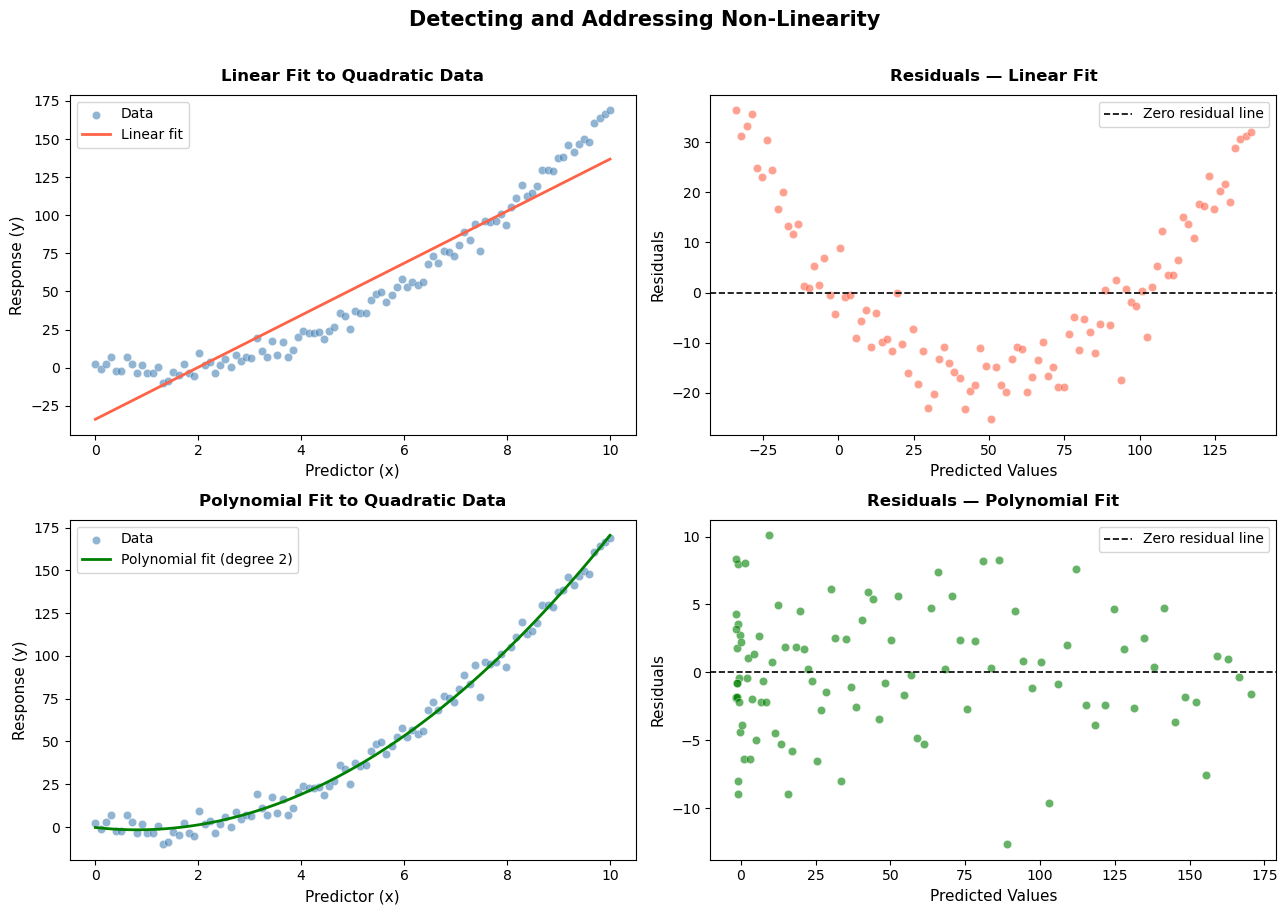

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x**2 - 3 * x + np.random.normal(0, 5, 100)

X = x.reshape(-1, 1)

# --- Fit linear model ---
lin = LinearRegression().fit(X, y)
y_pred_lin = lin.predict(X)
residuals_lin = y - y_pred_lin

# --- Fit polynomial model (degree 2) ---
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
pol = LinearRegression().fit(X_poly, y)
y_pred_pol = pol.predict(X_poly)
residuals_pol = y - y_pred_pol

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Detecting and Addressing Non-Linearity", fontsize=15, fontweight='bold', y=1.01)

# 1. Data + linear fit
axes[0, 0].scatter(x, y, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.4, label='Data')
axes[0, 0].plot(x, y_pred_lin, color='tomato', linewidth=2, label='Linear fit')
axes[0, 0].set_title("Linear Fit to Quadratic Data", fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel("Predictor (x)", fontsize=11)
axes[0, 0].set_ylabel("Response (y)", fontsize=11)
axes[0, 0].legend(fontsize=10)

# 2. Residual plot — linear (U-shape)
axes[0, 1].scatter(y_pred_lin, residuals_lin, alpha=0.6, color='tomato', edgecolors='white', linewidth=0.4)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero residual line')
axes[0, 1].set_title("Residuals — Linear Fit", fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel("Predicted Values", fontsize=11)
axes[0, 1].set_ylabel("Residuals", fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].annotate("U-shape indicates\nnon-linearity", xy=(80, -40), fontsize=10,
                     color='tomato', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='tomato'),
                     xytext=(120, -80))

# 3. Data + polynomial fit
axes[1, 0].scatter(x, y, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.4, label='Data')
axes[1, 0].plot(x, y_pred_pol, color='green', linewidth=2, label='Polynomial fit (degree 2)')
axes[1, 0].set_title("Polynomial Fit to Quadratic Data", fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Predictor (x)", fontsize=11)
axes[1, 0].set_ylabel("Response (y)", fontsize=11)
axes[1, 0].legend(fontsize=10)

# 4. Residual plot — polynomial (no pattern)
axes[1, 1].scatter(y_pred_pol, residuals_pol, alpha=0.6, color='green', edgecolors='white', linewidth=0.4)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero residual line')
axes[1, 1].set_title("Residuals — Polynomial Fit", fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel("Predicted Values", fontsize=11)
axes[1, 1].set_ylabel("Residuals", fontsize=11)
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("non_linearity.png", dpi=150, bbox_inches='tight')
plt.show()

The plot in the top left shows data with a poor linear fit with the associated u-shaped residual plot in the top right as the diagnostic signal of non-linearity. The bottom left plot shows the same data with a quadratic fit, and then the associated residual plot with no pattern, indicating that the issue was resolved.

### Issue 2: Correlation of error terms

A linear regression model assumes that the error terms are uncorrelated (each error term provides no information about the next error term), but correlations can occur among the error terms in cases such as time series data. This matters because the standard errors could be underestimated if correlation is present, leading to confidence intervals being narrower than they should be and p-values to be lower. Overall, correlated error terms can lead to overconfidence in a model. This can be detected by plotting the residuals from the model as a function of time. If the errors are uncorrelated there will be no pattern, but if they are positively correlated then there will be tracking in the residuals where the adjacent residuals have similar values.

A question that came up was what methods can be used to address correlations in error terms, as the section mentioned but did not directly address them. I researched how to handle autocorrelation in time series specifically, and found that the time trend can be included as a covariate in the model, including a lagged version of the outcome variable as the covariate predictor in the model, or using more complex methods like the ARIMA model to account for many dynamic processes occurring in time series data.

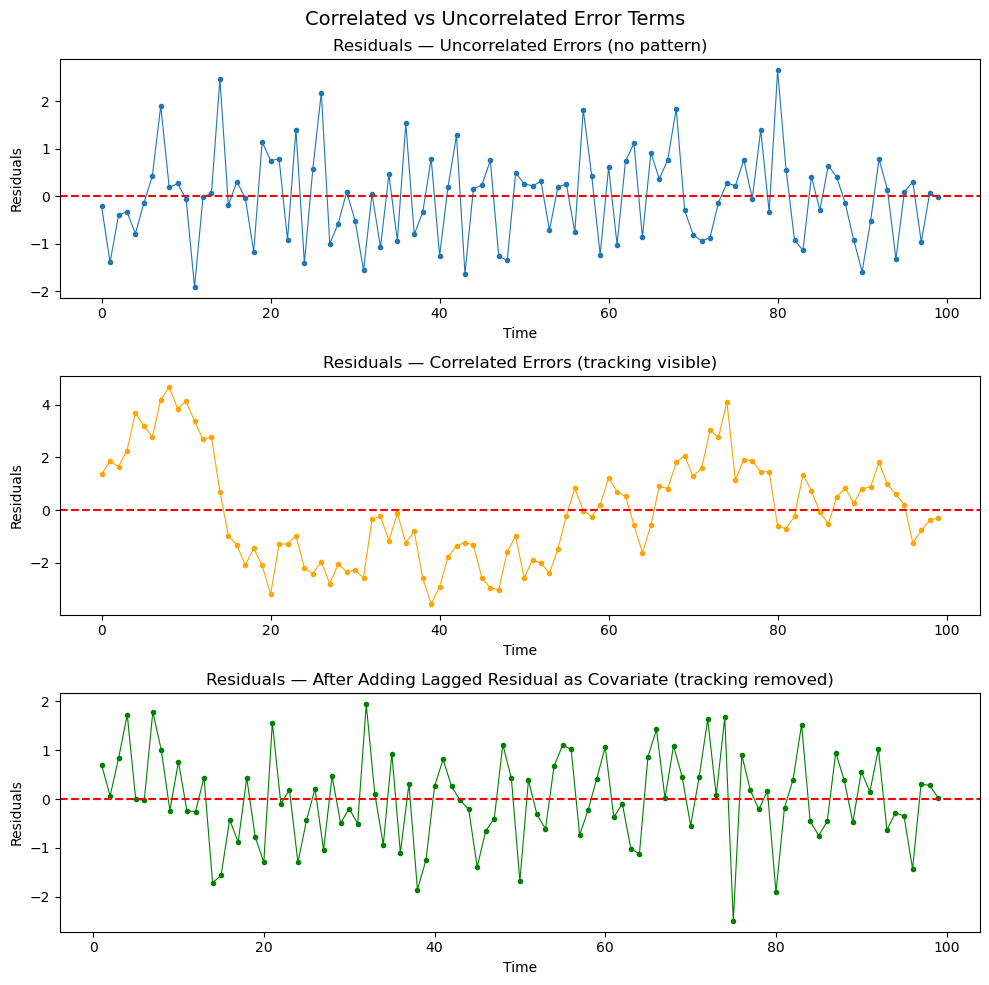

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 100
t = np.arange(n)

# --- Correlated errors via AR(1) process ---
rho = 0.9
errors_corr = np.zeros(n)
for i in range(1, n):
    errors_corr[i] = rho * errors_corr[i-1] + np.random.normal(0, 1)

errors_uncorr = np.random.normal(0, 1, n)

# True relationship: y = 0.5t + error
y_corr   = 0.5 * t + errors_corr
y_uncorr = 0.5 * t + errors_uncorr

T = t.reshape(-1, 1)

# --- Fit linear models ---
res_corr   = y_corr   - LinearRegression().fit(T, y_corr).predict(T)
res_uncorr = y_uncorr - LinearRegression().fit(T, y_uncorr).predict(T)

# --- Fix: include lagged residual as covariate ---
T_lag = np.column_stack([t[1:], y_corr[:-1]])  # time + previous y
res_fixed = y_corr[1:] - LinearRegression().fit(T_lag, y_corr[1:]).predict(T_lag)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle("Correlated vs Uncorrelated Error Terms", fontsize=14)

axes[0].plot(t, res_uncorr, marker='o', markersize=3, linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals — Uncorrelated Errors (no pattern)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residuals")

axes[1].plot(t, res_corr, marker='o', markersize=3, linewidth=0.8, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title("Residuals — Correlated Errors (tracking visible)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Residuals")

axes[2].plot(t[1:], res_fixed, marker='o', markersize=3, linewidth=0.8, color='green')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title("Residuals — After Adding Lagged Residual as Covariate (tracking removed)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig("correlated_errors.png", dpi=150)
plt.show()

The top plot shows residuals with no pattern, which is the ideal case and represents uncorrelated error terms. The middle plot shows residuals with clear tracking, which indicates the issue of correlated error terms. The bottom plot shows residuals after adding a lagged term as a covariate, which removed the correlation.

### Issue 3: Collinearity

Collinearity is when two or more predictor variables are closely related to one another, or collinear. This matters as it can be difficult to separate the individual effects of the collinear variables on the response. It also causes the standard error of the predicted coefficients to increase, reducing the power of the hypothesis test to correctly detect a non-zero coefficient. Collinearity can be detected by looking at a correlation matrix of the predictors, where large values in the matrix indicate highly correlated variables. However, this is only effective with two variables and can not detect multicollinearity. For multicollinearity, a variance inflation factor (VIF) can be computed for each variable, where a value of above 5 or 10 is a problematic amount of collinearity. To address collinearity, one can drop the problematic variables as they likely have redundant information with the correlated variables, or to combine the predictors into a single predictor.

A question I wanted to answer was whether dropping variables changes the VIF scores of other variables. I found that once you remove a variable, it is best to recalculate the VIF for all of the remaining variables before removing any more.

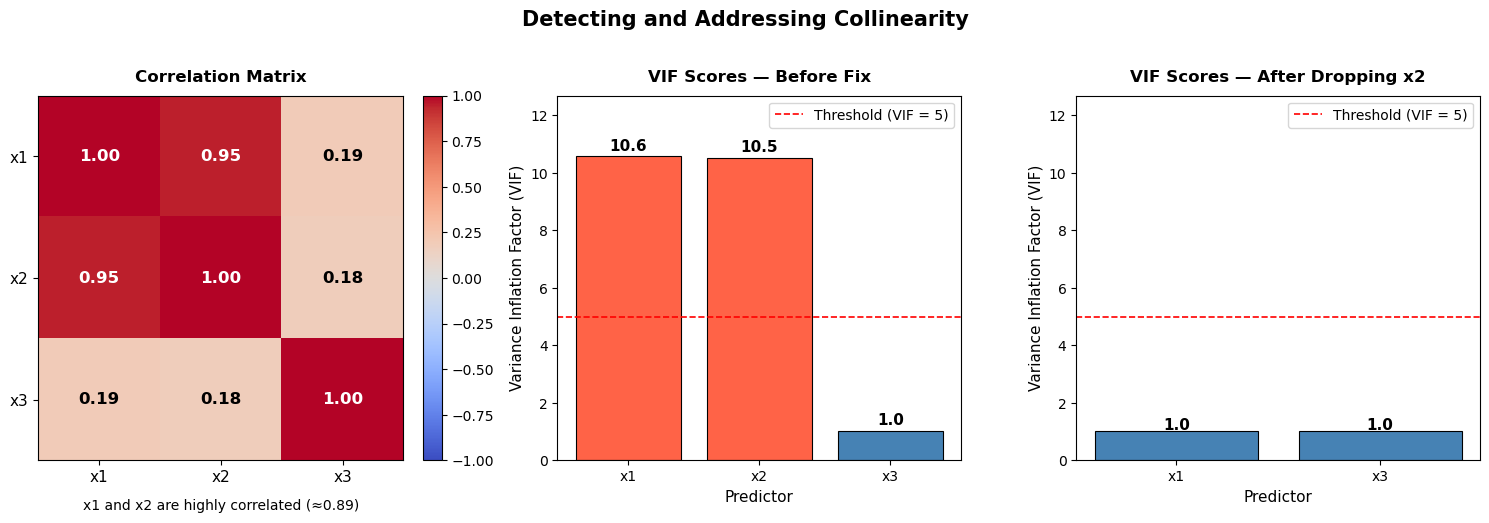

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)
n = 100

x1 = np.random.normal(0, 1, n)
x2 = x1 + np.random.normal(0, 0.3, n)  # collinear with x1
x3 = np.random.normal(0, 1, n)          # independent
y  = 2*x1 + 3*x3 + np.random.normal(0, 1, n)

df       = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
df_fixed = df[['x1', 'x3']]

vif_before = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
vif_after  = [variance_inflation_factor(df_fixed.values, i) for i in range(df_fixed.shape[1])]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Detecting and Addressing Collinearity", fontsize=15, fontweight='bold', y=1.02)

# 1. Correlation matrix
corr = df.corr()
im = axes[0].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(['x1','x2','x3'], fontsize=11)
axes[0].set_yticklabels(['x1','x2','x3'], fontsize=11)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
axes[0].set_title("Correlation Matrix", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("x1 and x2 are highly correlated (≈0.89)", fontsize=10, labelpad=10)
plt.colorbar(im, ax=axes[0], fraction=0.046)

# 2. VIF before
colors_before = ['tomato' if v > 5 else 'steelblue' for v in vif_before]
bars = axes[1].bar(['x1','x2','x3'], vif_before, color=colors_before, edgecolor='black', linewidth=0.8)
axes[1].axhline(5, color='red', linestyle='--', linewidth=1.2, label='Threshold (VIF = 5)')
for bar, v in zip(bars, vif_before):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title("VIF Scores — Before Fix", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Predictor", fontsize=11)
axes[1].set_ylabel("Variance Inflation Factor (VIF)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, max(vif_before) * 1.2)

# 3. VIF after
bars = axes[2].bar(['x1','x3'], vif_after, color='steelblue', edgecolor='black', linewidth=0.8)
axes[2].axhline(5, color='red', linestyle='--', linewidth=1.2, label='Threshold (VIF = 5)')
for bar, v in zip(bars, vif_after):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title("VIF Scores — After Dropping x2", fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel("Predictor", fontsize=11)
axes[2].set_ylabel("Variance Inflation Factor (VIF)", fontsize=11)
axes[2].legend(fontsize=10)
axes[2].set_ylim(0, max(vif_before) * 1.2)  # same y-axis scale for easy comparison

plt.tight_layout()
plt.savefig("collinearity.png", dpi=150, bbox_inches='tight')
plt.show()

The correlation matrix shows that the predictors x1 and x2 are highly correlated, with a score of 0.95. The middle plot shows the VIF scores of these variables being extremely high, around 10. The last plot shows the recalculated VIF scores of the predictors x1 and x3 after dropping x2, which were much lower at 1, solving the collinearity issue in the data.

### Generative AI reflection

I used Claude to write Python code to illustrate each of these problems in linear regression. For each issue, I created a prompt that said: "Based upon this description:", pasted the summary paragraph I previously wrote that explains what the problem is, why it matters, how to detect it, and how to address it, and then said "can you write me simple Python code that generates synthetic data that clearly illustrates the issue, produces plots making the issue visually clear where applicable, and produces additional plots showing how the issue can be addressed.". This prompt had enough context to perform correctly the first time on all prompts, and returned simple enough code for me to understand with packages that we have used in class. I generally found the plots very intuitive and similar to the ones provided in the textbook despite not providing any images as examples.